# WDRO

We have a model that can detect cybersecurity attacks in an IoT context and we want that model to be deployed in a micro-controller for live analysis.  
One of the challenge when doing machine learning detections of cybersecurity attacks is building a model robust to an attack on the model itself.  

In this part we are going to explore one technique to get a model more robust.


## What is WDRO ?

Wasserstein Distributionally Robust Optimization (WDRO) is a mathematical framework that can provide robustness to data shifts in machine learning models[^1].

Distributionally Robust Optimization (DRO) introduces a solution by considering the worst expectation of the cost function when the probability distribution belongs to a neighborhood around the empirical distribution [^1]. 

A recent push has been made towards wider neighborhoods notions for DRO lead by the WDRO formulation. Its ambiguity set relies on the Wasserstein optimal transport cost [^1]. We consider an ambiguity set—a "ball" of plausible distributions centered around a nominal distribution (e.g., the empirical distribution of training data), where the radius of the ball is defined by the Wasserstein distance. WDRO seeks to minimize the worst-case risk over all distributions within this Wasserstein ball, ensuring that the model performs well even if the true distribution differs from the training data within the specified radius [^2] [^3] [^4].


[^1]: [What is WDRO ?](https://skwdro.readthedocs.io/latest/wdro.html)  
[^2]: [Data-driven distributionally robust optimization using the Wasserstein metric: performance guarantees and tractable reformulations](https://link.springer.com/article/10.1007/s10107-017-1172-1)  
[^3]: [Wasserstein Distributionally Robust Optimization and Variation Regularization](https://pubsonline.informs.org/doi/10.1287/opre.2022.2383)  
[^4]: [Wasserstein Distributionally Robust Optimization: Theory and Applications in Machine Learning](arxiv.org/abs/1908.08729)

In [ ]:
#Importation of necessary libraries
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## Importation and pre-processing

We import the data and pre-processed it to train WDRO models on the same base than our previous model.

In [ ]:
loaded_pipeline = joblib.load('../jobs/preprocessing.joblib')
loaded_model = joblib.load('../jobs/logistic_regression_PCA_model.joblib')
data = pd.read_csv('../data/rt_iot2022.csv')

In [ ]:
X = data.drop('Attack_type', axis=1)
y = data['Attack_type']

from sklearn.preprocessing import OneHotEncoder

categorical_feature = ['proto', 'service']
onehot = OneHotEncoder(sparse_output = False)
encoded_categorical = onehot.fit_transform(data[categorical_feature])

encoded_df = pd.DataFrame(encoded_categorical, columns = onehot.get_feature_names_out(categorical_feature))
X_encoded = X.drop(categorical_feature, axis = 1)
X_encoded = pd.concat([X_encoded, encoded_df], axis = 1)
X_encoded.head()

,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl
0,38667,1883,32.011598,9,5,3,3,0.281148,0.156193,0.437341,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,51143,1883,31.883584,9,5,3,3,0.282277,0.156821,0.439097,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,44761,1883,32.124053,9,5,3,3,0.280164,0.155647,0.435811,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,60893,1883,31.961063,9,5,3,3,0.281593,0.156440,0.438033,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,51087,1883,31.902362,9,5,3,3,0.282111,0.156728,0.438839,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Training

First we plit the dataset into tran and test set.

In [ ]:
from sklearn.model_selection import train_test_split
X_preprocessed = loaded_pipeline.transform(X_encoded)
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state = 42)

Then we define 5 rho parameters so that we can train 5 models and compare them.

In [ ]:
from skwdro.linear_models import LogisticRegression as skwdroLogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rhos = [10**i for i in range(-5, 0)]  #definig rho values
classifiers = []

#definig classifiers for each rho value
for rho in rhos:
    classifiers.append(skwdroLogisticRegression(rho=rho, learning_rate=1e-3))

# rescaling the data to prevent errors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


for i in range(len(classifiers)):
    #Training classfier
    classifiers[i].fit(X_train_scaled, y_train)
    
    #prediction and test set
    y_pred = classifiers[i].predict(X_test_scaled)
    
    #Evaluation of model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    #adv = calculate_adversarial_accuracy(classifiers[i], X_test_scaled, y_test, eps=0.1)
    print(f"Rho: {rhos[i]:.6f} => Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.000010 => Accuracy: 0.966, Precision: 0.966, Recall: 0.966, F1: 0.965


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.000100 => Accuracy: 0.969, Precision: 0.968, Recall: 0.969, F1: 0.967


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.001000 => Accuracy: 0.966, Precision: 0.966, Recall: 0.966, F1: 0.965


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.010000 => Accuracy: 0.933, Precision: 0.946, Recall: 0.933, F1: 0.926


c:\Users\gaell\Documents\ml_courses\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Rho: 0.100000 => Accuracy: 0.908, Precision: 0.885, Recall: 0.908, F1: 0.890


## Testing our models

For now we can only see evaluation metrics on accuracy, recall and precision. The greater rho is the worse these metrics get on the models. But in this part we are not just evaluating the correctness of the models, we want to evaluate the robustness of the models.

So we are going to add Gaussian noise to the dataset and the test our dataset on this noisy dataset.

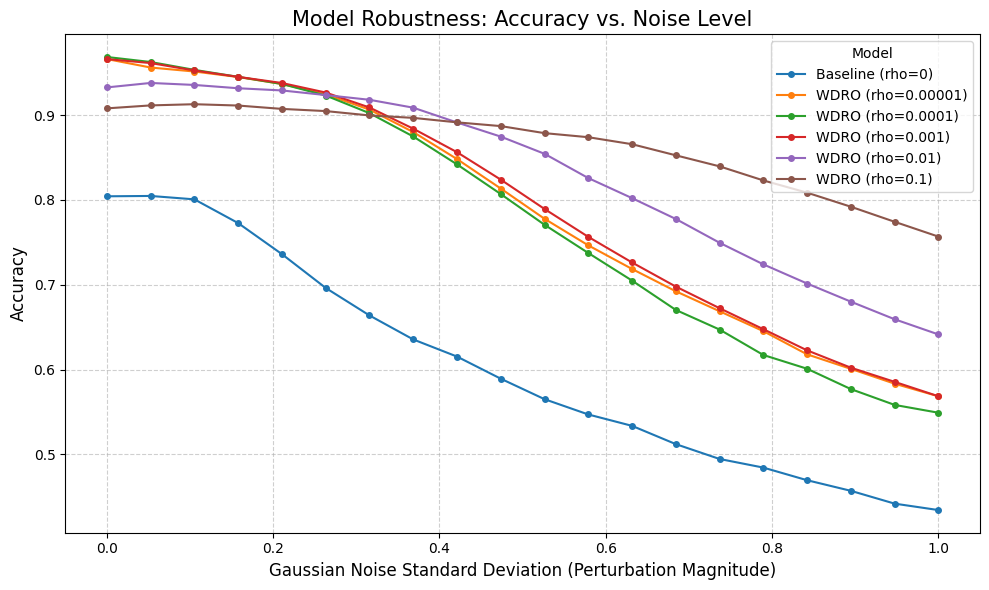

In [ ]:
def generate_noisy_data(X_test, noise_std):
    """Adds Gaussian noise to the test data."""
    noise = np.random.normal(0, noise_std, X_test.shape)
    return X_test + noise

def plot_stability(models_dict, X_test, y_test):
    """
    Generates and plots the stability curve for multiple models.

    Args:
        models_dict (dict): A dictionary of {'Label': trained_model_instance}.
        X_test (np.ndarray): The clean test features.
        y_test (np.ndarray): The test labels.
    """
    
    # Define the range of noise levels (standard deviation of the Gaussian noise)
    noise_levels = np.linspace(0.0, 1.0, 20) # 0.0 (clean) to 1.0 (very noisy)
    
    plt.figure(figsize=(10, 6))
    
    for label, model in models_dict.items():
        accuracies = []
        for std in noise_levels:
            # 1. Generate noisy data
            X_test_noisy = generate_noisy_data(X_test, std)
            
            # 2. Predict and calculate accuracy
            y_pred = model.predict(X_test_noisy)
            acc = accuracy_score(y_test, y_pred)
            accuracies.append(acc)
        
        # 3. Plot the stability curve
        plt.plot(noise_levels, accuracies, label=label, marker='o', markersize=4)

    # --- Plot Formatting ---
    plt.title('Model Robustness: Accuracy vs. Noise Level', fontsize=15)
    plt.xlabel('Gaussian Noise Standard Deviation (Perturbation Magnitude)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(title='Model', loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Group your models for plotting
models_to_test = {
    'Baseline (rho=0)': loaded_model,
    'WDRO (rho=0.00001)': classifiers[0],
    'WDRO (rho=0.0001)': classifiers[1],
    'WDRO (rho=0.001)': classifiers[2],
    'WDRO (rho=0.01)': classifiers[3],
    'WDRO (rho=0.1)': classifiers[4], 
}

# The most robust model will have the flattest line (least degradation)
plot_stability(models_to_test, X_test_scaled, y_test)

As we can see more rho is big, more the model is robust.

## Export

For further experimentation we are going to export all 5 models

In [ ]:
JOB_DIR = '../jobs/'
WDRO_DIR = 'wdro_models/'
model_filenames = [f'WDRO_{10**i}.joblib' for i in range(-5, 0)]

os.makedirs(os.path.join(JOB_DIR, WDRO_DIR), exist_ok=True)

for model in model_filenames:
    MODEL_PATH = os.path.join(JOB_DIR, WDRO_DIR, model)
    try:
        joblib.dump(model, MODEL_PATH)
        print(f"Model successfully exported to: {MODEL_PATH}")
    except Exception as e:
        print(f"An error occurred during export: {e}")

Model successfully exported to: ../jobs/wdro_models/WDRO_1e-05.joblib
Model successfully exported to: ../jobs/wdro_models/WDRO_0.0001.joblib
Model successfully exported to: ../jobs/wdro_models/WDRO_0.001.joblib
Model successfully exported to: ../jobs/wdro_models/WDRO_0.01.joblib
Model successfully exported to: ../jobs/wdro_models/WDRO_0.1.joblib
